# 1. Purpose

This notebook runs the **Direct speech-to-text translation pipeline**: English audio → `facebook/seamless-m4t-v2-large` → Chinese text. SeamlessM4T v2-large translates speech directly, without producing an intermediate English transcript.

The same notebook supports pilot and final datasets; change only `DATASET_MODE` in the configuration cell. This notebook performs frozen-model inference and computational timing only. Translation-quality evaluation (BLEU, chrF++, WER, statistical tests, and accent-performance conclusions) belongs in a separate evaluation notebook. Source metadata and audio are never modified.

# 2. Install and Import Required Libraries

This first code cell installs the small set of required packages and imports everything used below. It is designed for Google Colab, where PyTorch and torchaudio are normally preinstalled together. If installation changes package versions in an already-running kernel, restart the runtime once and run the notebook from the top.

In [23]:
%pip install -q "transformers>=4.40,<5" sentencepiece pandas numpy tqdm matplotlib transformers
%pip install torch==2.11.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu130
%pip install -U protobuf sentencepiece
%pip install hf_xet
%pip install torchcodec==0.11

import json
import platform
import random
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchaudio
import transformers
from tqdm.auto import tqdm
from transformers import AutoProcessor, SeamlessM4Tv2ForSpeechToText

print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 3. Constants and Configuration

This is the only configuration cell. To switch datasets, change only `DATASET_MODE` from `"pilot"` to `"final"`. Verify the two final paths before the final experiment. All clips use the same preprocessing, target language, and deterministic decoding settings. Set `RESUME_RUN_DIR` only when deliberately continuing an existing run folder; otherwise leave it as `None` for a unique run.

In [25]:
DATASET_MODE = "pilot"  # Change only this to "final" for the final dataset.

PILOT_METADATA_PATH = Path("../data/pilot_sample/pilot_sample_metadata.csv")
PILOT_AUDIO_DIR = Path("../data/pilot_sample/pilot_sample_audio")
FINAL_METADATA_PATH = Path("../data/final_sample/final_sample_600_per_group.csv")
FINAL_AUDIO_DIR = Path("../data/final_sample/final_sample_audio")

MODEL_ID = "facebook/seamless-m4t-v2-large"
MODEL_CLASS_NAME = "SeamlessM4Tv2ForSpeechToText"
TARGET_LANGUAGE = "cmn"  # SeamlessM4T language code for Mandarin Chinese.
OUTPUT_BASE_DIR = Path("../runs")
CHECKPOINT_EVERY = 50
SEED = 760
RESUME_RUN_DIR = None  # Example: Path("./runs/direct_run_1780000000")

GENERATION_KWARGS = {
    "num_beams": 5,
    "do_sample": False,
    "max_new_tokens": 256,
}

DATASET_PATHS = {
    "pilot": (PILOT_METADATA_PATH, PILOT_AUDIO_DIR),
    "final": (FINAL_METADATA_PATH, FINAL_AUDIO_DIR),
}
if DATASET_MODE not in DATASET_PATHS:
    raise ValueError(f"DATASET_MODE must be one of {list(DATASET_PATHS)}, not {DATASET_MODE!r}.")
METADATA_PATH, AUDIO_DIR = DATASET_PATHS[DATASET_MODE]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Dataset mode: {DATASET_MODE}")
print(f"Metadata: {METADATA_PATH}")
print(f"Audio directory: {AUDIO_DIR}")
print(f"Target language: {TARGET_LANGUAGE}")

Dataset mode: pilot
Metadata: ..\data\pilot_sample\pilot_sample_metadata.csv
Audio directory: ..\data\pilot_sample\pilot_sample_audio
Target language: cmn


# 4. Create Run Output Directory

A fresh execution creates `./runs/direct_run_{unix_timestamp}/`. If `RESUME_RUN_DIR` is set, that exact existing folder is reused and successfully completed rows can be skipped later.

In [26]:
RUN_TIMESTAMP = int(time.time())
RUN_STARTED_UTC = datetime.now(timezone.utc).isoformat()
RUN_DIR = Path(RESUME_RUN_DIR) if RESUME_RUN_DIR is not None else OUTPUT_BASE_DIR / f"direct_run_{RUN_TIMESTAMP}"
RUN_DIR.mkdir(parents=True, exist_ok=RESUME_RUN_DIR is not None)

PREDICTIONS_PATH = RUN_DIR / "direct_predictions.csv"
RUNTIME_PATH = RUN_DIR / "direct_runtime.csv"
ENVIRONMENT_PATH = RUN_DIR / "run_environment.json"
SUMMARY_PATH = RUN_DIR / "run_summary.json"
RUNTIME_FIGURE_PATH = RUN_DIR / "runtime_per_clip.png"
DURATION_FIGURE_PATH = RUN_DIR / "runtime_vs_audio_duration.png"

print(f"Run directory: {RUN_DIR.resolve()}")

Run directory: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693


# 5. Hardware and Environment Information

The next cell chooses CUDA when available, reports the execution environment, and saves it immediately. CPU inference is supported but will be slow for this model. Reported runtimes describe this hardware and configuration only; they are not universal model runtimes.

In [27]:
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
MODEL_DTYPE = torch.float16 if CUDA_AVAILABLE else torch.float32
GPU_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None
GPU_MEMORY_GB = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2) if CUDA_AVAILABLE else None

environment_info = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_started_utc": RUN_STARTED_UTC,
    "python_version": sys.version,
    "pytorch_version": torch.__version__,
    "torchaudio_version": torchaudio.__version__,
    "transformers_version": transformers.__version__,
    "cuda_available": CUDA_AVAILABLE,
    "cuda_version": torch.version.cuda,
    "device": str(DEVICE),
    "model_dtype": str(MODEL_DTYPE),
    "gpu_name": GPU_NAME,
    "gpu_memory_gb": GPU_MEMORY_GB,
    "platform": platform.platform(),
    "system": platform.system(),
    "model_id": MODEL_ID,
    "model_class": MODEL_CLASS_NAME,
    "target_language": TARGET_LANGUAGE,
    "dataset_mode": DATASET_MODE,
    "metadata_path": str(METADATA_PATH.resolve()),
    "audio_directory": str(AUDIO_DIR.resolve()),
    "generation_settings": GENERATION_KWARGS,
    "seed": SEED,
}
ENVIRONMENT_PATH.write_text(json.dumps(environment_info, indent=2, ensure_ascii=False), encoding="utf-8")

for key, value in environment_info.items():
    print(f"{key}: {value}")
if not CUDA_AVAILABLE:
    warnings.warn("CUDA is not available. SeamlessM4T v2-large inference will run on CPU and may be very slow.")

run_timestamp: 1788054693
run_started_utc: 2026-08-30T01:51:33.798381+00:00
python_version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
pytorch_version: 2.11.0+cu130
torchaudio_version: 2.11.0+cu130
transformers_version: 4.57.6
cuda_available: True
cuda_version: 13.0
device: cuda
model_dtype: torch.float16
gpu_name: NVIDIA GeForce GTX 1660 Ti
gpu_memory_gb: 6.0
platform: Windows-11-10.0.26200-SP0
system: Windows
model_id: facebook/seamless-m4t-v2-large
model_class: SeamlessM4Tv2ForSpeechToText
target_language: cmn
dataset_mode: pilot
metadata_path: D:\projects\cs760-accent-st-robustness-ml-research\data\pilot_sample\pilot_sample_metadata.csv
audio_directory: D:\projects\cs760-accent-st-robustness-ml-research\data\pilot_sample\pilot_sample_audio
generation_settings: {'num_beams': 5, 'do_sample': False, 'max_new_tokens': 256}
seed: 760


# 6. Load and Validate Input Metadata

The selected CSV is loaded without renaming, deleting, reordering, or changing its source columns. This cell reports a compact structural review, common duplicate checks, missing values, speaker/accent counts when available, and duration or sentence-length statistics when suitable fields exist.

In [28]:
if not METADATA_PATH.is_file():
    raise FileNotFoundError(f"Metadata CSV not found: {METADATA_PATH.resolve()}")
if not AUDIO_DIR.is_dir():
    raise NotADirectoryError(f"Audio directory not found: {AUDIO_DIR.resolve()}")

metadata_df = pd.read_csv(METADATA_PATH)
original_columns = metadata_df.columns.tolist()
if "direct_translation" in original_columns:
    raise ValueError("Input metadata already contains 'direct_translation'; refusing to overwrite it.")
if metadata_df.columns.duplicated().any():
    raise ValueError("Input metadata contains duplicate column names, so exact output preservation is ambiguous.")

print(f"Dataset mode: {DATASET_MODE}")
print(f"Total samples: {len(metadata_df):,}")
print(f"Columns ({len(original_columns)}): {original_columns}")
print(f"Fully duplicated rows: {metadata_df.duplicated().sum():,}")

speaker_column = next((c for c in ["client_id", "speaker_id", "speaker"] if c in metadata_df.columns), None)
if speaker_column:
    print(f"Unique speakers ({speaker_column}): {metadata_df[speaker_column].nunique(dropna=True):,}")
if "primary_accent" in metadata_df.columns:
    print("\nAccent counts:")
    display(metadata_df["primary_accent"].value_counts(dropna=False).rename("count").to_frame())

important_candidates = ["clip", "path", "audio", "audio_path", "sentence", "sentence_id", "client_id", "speaker_id", "primary_accent", "duration", "duration_sec"]
important_columns = [c for c in important_candidates if c in metadata_df.columns]
if important_columns:
    print("\nMissing values in important fields:")
    display(metadata_df[important_columns].isna().sum().rename("missing").to_frame())

id_column = next((c for c in ["sample_id", "sentence_id", "clip", "path"] if c in metadata_df.columns), None)
if id_column:
    print(f"Duplicate values in {id_column}: {metadata_df[id_column].duplicated().sum():,}")

duration_column = next((c for c in ["audio_duration_sec", "duration_sec", "duration"] if c in metadata_df.columns), None)
if duration_column:
    print(f"\nDuration statistics from '{duration_column}':")
    display(pd.to_numeric(metadata_df[duration_column], errors="coerce").describe().to_frame())

sentence_column = next((c for c in ["sentence", "text", "transcript"] if c in metadata_df.columns), None)
if sentence_column:
    sentence_lengths = metadata_df[sentence_column].fillna("").astype(str).str.split().str.len()
    print(f"\nSentence length statistics in words from '{sentence_column}':")
    display(sentence_lengths.describe().to_frame("word_count"))

display(metadata_df.head(5))

Dataset mode: pilot
Total samples: 21
Columns (20): ['path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment', 'primary_accent', 'sentence_norm', 'clip', 'duration[ms]', 'sentence_len_words', 'max_plausible_words', 'sentence_len_chars', 'sample_id']
Fully duplicated rows: 0

Accent counts:


,count
primary_accent,
England English,3
Filipino,3
Hong Kong English,3
"India and South Asia (India, Pakistan, Sri Lanka)",3
Malaysian English,3
"Southern African (South Africa, Zimbabwe, Namibia)",3
United States English,3



Missing values in important fields:


,missing
clip,0
path,0
sentence,0
sentence_id,0
primary_accent,0


Duplicate values in sample_id: 0

Sentence length statistics in words from 'sentence':


,word_count
count,21.000000
mean,8.904762
std,3.269629
min,4.000000
25%,7.000000
50%,8.000000
75%,11.000000
max,17.000000


,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,primary_accent,sentence_norm,clip,duration[ms],sentence_len_words,max_plausible_words,sentence_len_chars,sample_id
0,common_voice_en_17298654.mp3,287a2c05bd57146ad187d267e8e20ae1e47f4de2d744ad...,Where did they come from?,NaN,2,0,fifties,male_masculine,England English,NaN,en,NaN,England English,where did they come from,common_voice_en_17298654.mp3,3072,5,12.288,25,spk_1267
1,common_voice_en_17266900.mp3,317c6928c294b518e2ed26b7f086ec9d,"The very next day, he woke refreshed.",NaN,2,0,teens,male_masculine,England English,NaN,en,NaN,England English,the very next day he woke refreshed,common_voice_en_17266900.mp3,4272,7,17.088,37,spk_0863
2,common_voice_en_19612259.mp3,1ad1e6d5b323638cca586ebd4726a973eb4170096fb584...,Colman met the duo when they were all students...,NaN,2,0,fifties,male_masculine,England English,NaN,en,NaN,England English,colman met the duo when they were all students...,common_voice_en_19612259.mp3,5952,12,23.808,71,spk_0736
3,common_voice_en_15713.mp3,b2b1850551c3eef44826c0281d41710d9f184470aec23f...,Insert your card to identify yourself.,NaN,3,1,twenties,female_feminine,Filipino,NaN,en,NaN,Filipino,insert your card to identify yourself,common_voice_en_15713.mp3,3288,6,13.152,38,spk_0110
4,common_voice_en_17281012.mp3,5938d71e165602a71eb51957090de2fa,We would prefer for your search to be carried ...,NaN,2,0,fourties,male_masculine,Filipino,NaN,en,NaN,Filipino,we would prefer for your search to be carried ...,common_voice_en_17281012.mp3,4584,11,18.336,61,spk_0900


# 7. Resolve and Validate Audio Files

The notebook selects one existing filename/path column and resolves relative entries against `AUDIO_DIR`. Absolute entries are accepted. The resolved paths are kept only in a separate working series and are never appended to the clean prediction CSV. Missing files are shown before inference; each will later receive a failed diagnostic row rather than stopping the run.

In [29]:
AUDIO_COLUMN_CANDIDATES = ["clip", "path", "audio", "audio_file", "audio_filename", "filename", "file"]
AUDIO_COLUMN = next((c for c in AUDIO_COLUMN_CANDIDATES if c in metadata_df.columns), None)
if AUDIO_COLUMN is None:
    raise KeyError(f"No audio filename/path column found. Expected one of: {AUDIO_COLUMN_CANDIDATES}")

def resolve_audio_path(value):
    if pd.isna(value) or not str(value).strip():
        return None
    candidate = Path(str(value).strip()).expanduser()
    return candidate if candidate.is_absolute() else AUDIO_DIR / candidate

working_audio_paths = metadata_df[AUDIO_COLUMN].map(resolve_audio_path)
audio_exists = working_audio_paths.map(lambda p: p is not None and p.is_file())
missing_paths = working_audio_paths[~audio_exists]

print(f"Audio column: {AUDIO_COLUMN}")
print(f"Valid audio files: {audio_exists.sum():,}")
print(f"Missing/unresolved audio files: {(~audio_exists).sum():,}")
if len(missing_paths):
    display(pd.DataFrame({"row_index": missing_paths.index, "missing_audio": missing_paths.astype(str)}).head(50))
    missing_fraction = len(missing_paths) / max(len(metadata_df), 1)
    if missing_fraction >= 0.10:
        warnings.warn(f"{missing_fraction:.1%} of audio files are missing. Check AUDIO_DIR and metadata paths before the main run.")
if not audio_exists.any():
    raise FileNotFoundError("No valid audio files were resolved; inference cannot start.")

Audio column: clip
Valid audio files: 21
Missing/unresolved audio files: 0


# 8. Timing Methodology

Per-clip wall-clock runtime covers the required path from opening/loading the audio through mono conversion, resampling, processor feature creation, SeamlessM4T v2 text generation, and Chinese text decoding. Model download/loading is excluded. Exactly one warm-up inference is performed and excluded.

Timing uses `time.perf_counter()`. On CUDA, `torch.cuda.synchronize()` is called immediately before the timer and after all timed GPU work. Inference uses `torch.inference_mode()`. One clip is processed at a time for clear, reproducible latency. Real-time factor (RTF) is `runtime_sec / audio_duration_sec` when duration is valid.

In [30]:
def synchronize_device():
    """Wait for queued CUDA work so wall-clock timings are accurate."""
    if CUDA_AVAILABLE:
        torch.cuda.synchronize()

print("Timing helper ready. Model loading and warm-up will remain outside measured clip runtimes.")

Timing helper ready. Model loading and warm-up will remain outside measured clip runtimes.


# 9. Load SeamlessM4T v2-large

The processor and model are loaded exactly once. CUDA uses FP16 to fit common Colab T4-class GPUs; CPU uses FP32 for reliability. The general SeamlessM4T v2 class follows the documented speech-to-text generation path with `generate_speech=False`. Loading time is intentionally outside all clip timers.

In [31]:
try:
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, dtype=MODEL_DTYPE)
    model.to(DEVICE)
    model.eval()
except Exception as exc:
    raise RuntimeError(f"Failed to load {MODEL_ID}. Check network access, memory, and package versions.") from exc

MODEL_SAMPLE_RATE = int(getattr(processor.feature_extractor, "sampling_rate", 16000))
print(f"Loaded {MODEL_CLASS_NAME} from {MODEL_ID} once on {DEVICE} with {MODEL_DTYPE}.")
print(f"Required sample rate: {MODEL_SAMPLE_RATE} Hz")

Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.80s/it]


Loaded SeamlessM4Tv2ForSpeechToText from facebook/seamless-m4t-v2-large once on cuda with torch.float16.
Required sample rate: 16000 Hz


# 10. Audio Preprocessing Helper

Every clip receives the same minimal preprocessing: load, convert multiple channels to mono by averaging, and resample only when necessary. No noise reduction, accent normalization, speed change, augmentation, or content-changing transform is applied.

In [32]:
def load_audio_for_model(audio_path, target_sample_rate=MODEL_SAMPLE_RATE):
    """Load one file, return a mono float32 NumPy waveform and duration."""
    waveform, source_sample_rate = torchaudio.load(str(audio_path))
    if waveform.ndim != 2 or waveform.shape[1] == 0:
        raise ValueError(f"Audio has an invalid shape: {tuple(waveform.shape)}")
    waveform = waveform.mean(dim=0)
    if source_sample_rate != target_sample_rate:
        waveform = torchaudio.functional.resample(waveform, source_sample_rate, target_sample_rate)
    waveform = waveform.to(torch.float32).contiguous()
    duration_sec = waveform.numel() / float(target_sample_rate)
    if duration_sec <= 0:
        raise ValueError("Audio is empty.")
    return waveform.cpu().numpy(), duration_sec

# 11. Direct Translation Function

This reusable function performs direct speech-to-Chinese text translation with the fixed configuration. It contains no accent-specific logic and does not calculate any quality metric.

In [33]:
def direct_translate_single(waveform, sampling_rate=MODEL_SAMPLE_RATE):
    inputs = processor(audio=waveform, sampling_rate=sampling_rate, return_tensors="pt")
    model_inputs = {}
    for name, tensor in inputs.items():
        if torch.is_floating_point(tensor):
            model_inputs[name] = tensor.to(device=DEVICE, dtype=MODEL_DTYPE)
        else:
            model_inputs[name] = tensor.to(DEVICE)
    with torch.inference_mode():
        generated = model.generate(
            **model_inputs,
            tgt_lang=TARGET_LANGUAGE,
            **GENERATION_KWARGS,
        )
    token_ids = generated[0]
    if token_ids.ndim > 1:
        token_ids = token_ids[0]
    translation = processor.decode(token_ids.detach().cpu().tolist(), skip_special_tokens=True).strip()
    if not translation:
        raise ValueError("The model returned an empty translation.")
    return translation

# 12. Warm-Up

One valid input clip is translated before measured inference. This confirms the complete pipeline and warms GPU kernels. Its output and runtime are not saved in either results table or timing statistics.

In [34]:
warmup_index = audio_exists[audio_exists].index[0]
warmup_waveform, _ = load_audio_for_model(working_audio_paths.loc[warmup_index])
_warmup_translation = direct_translate_single(warmup_waveform)
if CUDA_AVAILABLE:
    torch.cuda.synchronize()
print("Direct pipeline warm-up complete.")

Direct pipeline warm-up complete.


# 13. Prepare Prediction and Runtime Tables

Create the clean prediction table and the separate diagnostic table. The prediction table preserves every input column in its original order and adds only `direct_translation`. If `RESUME_RUN_DIR` points to a compatible checkpoint, previously saved translations and diagnostics are restored.

In [35]:
# Keep runtime/status/error fields out of the clean prediction table.
RUNTIME_COLUMNS = [
    "sample_index", "sample_id", "client_id", "sentence_id",
    "primary_accent", AUDIO_COLUMN, "audio_duration_sec",
    "direct_runtime_sec", "direct_realtime_factor",
    "direct_status", "direct_error",
]
RUNTIME_COLUMNS = list(dict.fromkeys(RUNTIME_COLUMNS))
EXPECTED_PREDICTION_COLUMNS = original_columns + ["direct_translation"]

predictions_df = metadata_df.copy(deep=True)
predictions_df["direct_translation"] = pd.NA
runtime_df = pd.DataFrame(columns=RUNTIME_COLUMNS)

# A deliberate resume is allowed only when the saved files match this dataset.
if RESUME_RUN_DIR is not None and PREDICTIONS_PATH.is_file() and RUNTIME_PATH.is_file():
    saved_predictions = pd.read_csv(PREDICTIONS_PATH)
    saved_runtime = pd.read_csv(RUNTIME_PATH)
    if saved_predictions.columns.tolist() != EXPECTED_PREDICTION_COLUMNS:
        raise ValueError("Resume prediction columns do not match the current metadata schema.")
    if len(saved_predictions) != len(metadata_df):
        raise ValueError("Resume prediction row count does not match the current metadata.")
    predictions_df["direct_translation"] = saved_predictions["direct_translation"]
    runtime_df = saved_runtime.reindex(columns=RUNTIME_COLUMNS)
    print(f"Loaded checkpoint with {len(runtime_df):,} diagnostic rows.")

successful_indices = set(
    pd.to_numeric(
        runtime_df.loc[runtime_df["direct_status"].eq("success"), "sample_index"],
        errors="coerce",
    ).dropna().astype(int)
)
print(f"Already successful and eligible to skip: {len(successful_indices):,}")

Already successful and eligible to skip: 0


# 14. Define Checkpoint Helpers

These small helpers safely extract optional identifiers and save both current tables. The main loop calls the checkpoint writer periodically and immediately after a failure.

In [36]:
def diagnostic_value(row, name):
    """Return an optional metadata value without requiring that column."""
    return row[name] if name in row.index else pd.NA

def save_checkpoint():
    """Write current predictions and diagnostics into this run directory."""
    predictions_df.to_csv(PREDICTIONS_PATH, index=False)
    runtime_df.reindex(columns=RUNTIME_COLUMNS).to_csv(RUNTIME_PATH, index=False)

# 15. Define Single-Sample Processing

Process one metadata row from audio loading through Chinese text decoding. The timer includes audio preprocessing and inference, but not model loading or warm-up. Every outcome is returned as a translation plus one compact diagnostic record.

In [37]:
def process_single_sample(sample_index):
    """Translate one clip and return (translation, diagnostic)."""
    row = metadata_df.iloc[sample_index]
    audio_path = working_audio_paths.iloc[sample_index]
    translation = pd.NA
    audio_duration_sec = np.nan
    runtime_sec = np.nan
    realtime_factor = np.nan
    status = "failed"
    error_message = ""
    start_time = None

    try:
        if audio_path is None or not audio_path.is_file():
            raise FileNotFoundError(f"Audio file not found: {audio_path}")

        # Synchronization brackets all timed GPU work for valid wall-clock latency.
        synchronize_device()
        start_time = time.perf_counter()
        waveform, audio_duration_sec = load_audio_for_model(audio_path)
        translation = direct_translate_single(waveform)
        synchronize_device()
        runtime_sec = time.perf_counter() - start_time
        realtime_factor = runtime_sec / audio_duration_sec
        status = "success"
    except Exception as exc:
        synchronize_device()
        if start_time is not None:
            runtime_sec = time.perf_counter() - start_time
        error_message = f"{type(exc).__name__}: {exc}"

    diagnostic = {
        "sample_index": sample_index,
        "sample_id": diagnostic_value(row, "sample_id"),
        "client_id": diagnostic_value(row, "client_id"),
        "sentence_id": diagnostic_value(row, "sentence_id"),
        "primary_accent": diagnostic_value(row, "primary_accent"),
        AUDIO_COLUMN: diagnostic_value(row, AUDIO_COLUMN),
        "audio_duration_sec": audio_duration_sec,
        "direct_runtime_sec": runtime_sec,
        "direct_realtime_factor": realtime_factor,
        "direct_status": status,
        "direct_error": error_message,
    }
    return translation, diagnostic

# 16. Translate All Samples and Save Outputs

Run one clip at a time with a progress bar. Successful resumed rows are skipped; failed rows are retried. An individual error is recorded without stopping the dataset. Checkpoints are written every `CHECKPOINT_EVERY` processed samples, after each failure, and once at completion.

In [38]:
processed_this_session = 0
translation_column_index = predictions_df.columns.get_loc("direct_translation")

for sample_index in tqdm(range(len(metadata_df)), desc="Direct translation", unit="clip"):
    if sample_index in successful_indices:
        continue

    translation, diagnostic = process_single_sample(sample_index)
    predictions_df.iat[sample_index, translation_column_index] = translation

    # Replace an older failed diagnostic when a resumed row is retried.
    runtime_df = runtime_df[runtime_df["sample_index"].astype(str) != str(sample_index)]
    runtime_df = pd.concat([runtime_df, pd.DataFrame([diagnostic])], ignore_index=True)
    processed_this_session += 1

    should_checkpoint = (
        diagnostic["direct_status"] == "failed"
        or processed_this_session % CHECKPOINT_EVERY == 0
    )
    if should_checkpoint:
        save_checkpoint()

# Sort diagnostics into input order and write the completed tables.
runtime_df["sample_index"] = pd.to_numeric(runtime_df["sample_index"], errors="coerce")
runtime_df = runtime_df.sort_values("sample_index", kind="stable").reset_index(drop=True)
save_checkpoint()
print(f"Saved predictions: {PREDICTIONS_PATH.resolve()}")
print(f"Saved runtime diagnostics: {RUNTIME_PATH.resolve()}")

Direct translation: 100%|██████████| 21/21 [00:59<00:00,  2.83s/clip]

Saved predictions: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\direct_predictions.csv
Saved runtime diagnostics: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\direct_runtime.csv


# 17. Runtime Summary

Only successful measured clips contribute to latency and RTF statistics. The optional accent table is descriptive computational reporting only; runtime differences must not be interpreted as accent sensitivity or translation-quality differences.

In [39]:
success_mask = runtime_df["direct_status"].eq("success")
successful_runtime = pd.to_numeric(runtime_df.loc[success_mask, "direct_runtime_sec"], errors="coerce").dropna()
successful_rtf = pd.to_numeric(runtime_df.loc[success_mask, "direct_realtime_factor"], errors="coerce").dropna()

runtime_summary = {
    "total_samples": int(len(metadata_df)),
    "successful_samples": int(success_mask.sum()),
    "failed_samples": int((~success_mask).sum()),
    "total_inference_runtime_sec": float(successful_runtime.sum()),
    "mean_runtime_sec": float(successful_runtime.mean()) if len(successful_runtime) else None,
    "median_runtime_sec": float(successful_runtime.median()) if len(successful_runtime) else None,
    "min_runtime_sec": float(successful_runtime.min()) if len(successful_runtime) else None,
    "max_runtime_sec": float(successful_runtime.max()) if len(successful_runtime) else None,
    "std_runtime_sec": float(successful_runtime.std()) if len(successful_runtime) > 1 else None,
    "mean_realtime_factor": float(successful_rtf.mean()) if len(successful_rtf) else None,
    "median_realtime_factor": float(successful_rtf.median()) if len(successful_rtf) else None,
}
display(pd.Series(runtime_summary, name="value").to_frame())

if "primary_accent" in runtime_df.columns and runtime_df["primary_accent"].notna().any():
    accent_runtime_summary = (
        runtime_df.loc[success_mask]
        .assign(direct_runtime_sec=lambda d: pd.to_numeric(d["direct_runtime_sec"], errors="coerce"))
        .groupby("primary_accent", dropna=False)["direct_runtime_sec"]
        .agg(["count", "mean", "median", "min", "max"])
    )
    print("Descriptive runtime by accent (computational only):")
    display(accent_runtime_summary)

,value
total_samples,21.000000
successful_samples,21.000000
failed_samples,0.000000
total_inference_runtime_sec,59.268458
mean_runtime_sec,2.822308
median_runtime_sec,2.843769
min_runtime_sec,1.572243
max_runtime_sec,4.157656
std_runtime_sec,0.750286
mean_realtime_factor,0.638430


Descriptive runtime by accent (computational only):


,count,mean,median,min,max
primary_accent,,,,,
England English,3,2.843504,3.097606,1.733864,3.699042
Filipino,3,2.750047,2.430635,2.281092,3.538415
Hong Kong English,3,2.848890,2.988878,2.398466,3.159325
"India and South Asia (India, Pakistan, Sri Lanka)",3,3.166392,2.843769,2.518583,4.136825
Malaysian English,3,2.510129,2.395374,1.572243,3.562772
"Southern African (South Africa, Zimbabwe, Namibia)",3,2.679437,2.150068,1.730589,4.157656
United States English,3,2.957752,2.869706,2.588332,3.415220


# 18. Runtime Visualisation

The required figure plots measured Direct-pipeline wall-clock latency by sample index. A second simple scatter plot is saved when valid audio durations are available.

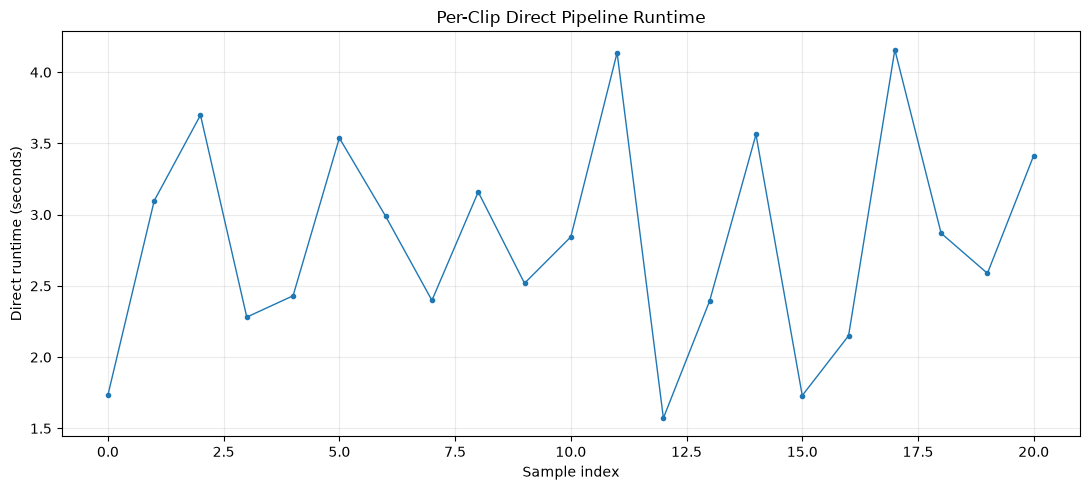

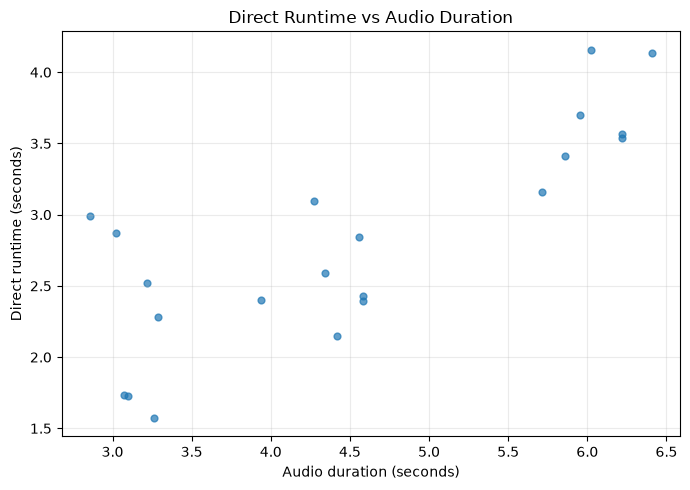

Saved runtime figure: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\runtime_per_clip.png


In [40]:
plot_df = runtime_df.loc[success_mask].copy()
plot_df["sample_index"] = pd.to_numeric(plot_df["sample_index"], errors="coerce")
plot_df["direct_runtime_sec"] = pd.to_numeric(plot_df["direct_runtime_sec"], errors="coerce")
plot_df["audio_duration_sec"] = pd.to_numeric(plot_df["audio_duration_sec"], errors="coerce")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(plot_df["sample_index"], plot_df["direct_runtime_sec"], marker="o", markersize=3, linewidth=1)
ax.set(title="Per-Clip Direct Pipeline Runtime", xlabel="Sample index", ylabel="Direct runtime (seconds)")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RUNTIME_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

duration_plot_df = plot_df.dropna(subset=["audio_duration_sec", "direct_runtime_sec"])
if len(duration_plot_df):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(duration_plot_df["audio_duration_sec"], duration_plot_df["direct_runtime_sec"], alpha=0.7, s=24)
    ax.set(title="Direct Runtime vs Audio Duration", xlabel="Audio duration (seconds)", ylabel="Direct runtime (seconds)")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(DURATION_FIGURE_PATH, dpi=160, bbox_inches="tight")
    plt.show()
print(f"Saved runtime figure: {RUNTIME_FIGURE_PATH.resolve()}")

# 19. Save Run Summary

The run summary combines configuration, completion counts, timing statistics, hardware identity, and output paths in a machine-readable JSON file. The environment JSON was saved before inference and remains alongside it.

In [41]:
run_summary = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_started_utc": RUN_STARTED_UTC,
    "run_finished_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_mode": DATASET_MODE,
    "number_of_input_samples": len(metadata_df),
    "model_id": MODEL_ID,
    "target_language": TARGET_LANGUAGE,
    "device": str(DEVICE),
    "gpu_name": GPU_NAME,
    **runtime_summary,
    "output_files": {
        "predictions_csv": str(PREDICTIONS_PATH.resolve()),
        "runtime_csv": str(RUNTIME_PATH.resolve()),
        "environment_json": str(ENVIRONMENT_PATH.resolve()),
        "runtime_figure": str(RUNTIME_FIGURE_PATH.resolve()),
        "duration_figure": str(DURATION_FIGURE_PATH.resolve()) if DURATION_FIGURE_PATH.exists() else None,
    },
}
SUMMARY_PATH.write_text(json.dumps(run_summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved run summary: {SUMMARY_PATH.resolve()}")

Saved run summary: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\run_summary.json


# 20. Final Validation

This cell reloads the written CSVs and checks row count, exact metadata preservation, column order, clean output separation, success/failure consistency, and the required files. It compares source metadata values against the prediction metadata columns; it does not write to source files.

In [42]:
written_predictions = pd.read_csv(PREDICTIONS_PATH)
written_runtime = pd.read_csv(RUNTIME_PATH)
written_source_metadata = pd.read_csv(METADATA_PATH)

validation_checks = {
    "prediction_rows_match_input": len(written_predictions) == len(metadata_df),
    "original_columns_preserved": all(c in written_predictions.columns for c in original_columns),
    "original_column_order_preserved": written_predictions.columns.tolist()[:len(original_columns)] == original_columns,
    "only_direct_translation_appended": written_predictions.columns.tolist() == EXPECTED_PREDICTION_COLUMNS,
    "source_metadata_values_preserved": written_predictions[original_columns].equals(written_source_metadata[original_columns]),
    "runtime_csv_exists": RUNTIME_PATH.is_file(),
    "required_output_files_exist": all(p.is_file() for p in [PREDICTIONS_PATH, RUNTIME_PATH, ENVIRONMENT_PATH, SUMMARY_PATH, RUNTIME_FIGURE_PATH]),
    "all_successes_have_translation": written_predictions.loc[written_runtime.query("direct_status == 'success'")["sample_index"].astype(int), "direct_translation"].fillna("").astype(str).str.strip().ne("").all(),
    "failed_samples_have_diagnostics": written_runtime.query("direct_status == 'failed'")["direct_error"].fillna("").astype(str).str.strip().ne("").all(),
}
validation_checks["source_files_not_modified_by_notebook"] = True  # All notebook writes target RUN_DIR only.

validation_df = pd.Series(validation_checks, name="passed").to_frame()
display(validation_df)
if not all(validation_checks.values()):
    failed_checks = [name for name, passed in validation_checks.items() if not passed]
    raise AssertionError(f"Final validation failed: {failed_checks}")
print("Final validation passed: outputs are complete and structurally consistent.")

,passed
prediction_rows_match_input,True
original_columns_preserved,True
original_column_order_preserved,True
only_direct_translation_appended,True
source_metadata_values_preserved,True
runtime_csv_exists,True
required_output_files_exist,True
all_successes_have_translation,True
failed_samples_have_diagnostics,True
source_files_not_modified_by_notebook,True


Final validation passed: outputs are complete and structurally consistent.


# 21. Final Run Summary

The final cell gives a compact handoff summary so completion status and all output locations are immediately visible.

In [43]:
def format_number(value, decimals=3):
    return "N/A" if value is None or pd.isna(value) else f"{value:.{decimals}f}"

print(f"Dataset mode: {DATASET_MODE.upper()}")
print(f"Model: {MODEL_ID}")
print(f"Target: Chinese ({TARGET_LANGUAGE})")
print(f"Device: {DEVICE}")
print(f"GPU: {GPU_NAME or 'N/A'}")
print()
print(f"Samples: {runtime_summary['total_samples']:,}")
print(f"Successful: {runtime_summary['successful_samples']:,}")
print(f"Failed: {runtime_summary['failed_samples']:,}")
print()
print(f"Total inference runtime: {format_number(runtime_summary['total_inference_runtime_sec'])} sec")
print(f"Mean sec/clip: {format_number(runtime_summary['mean_runtime_sec'])}")
print(f"Median sec/clip: {format_number(runtime_summary['median_runtime_sec'])}")
print(f"Mean RTF: {format_number(runtime_summary['mean_realtime_factor'])}")
print()
print(f"Predictions: {PREDICTIONS_PATH.resolve()}")
print(f"Runtime details: {RUNTIME_PATH.resolve()}")
print(f"Environment: {ENVIRONMENT_PATH.resolve()}")
print(f"Run summary: {SUMMARY_PATH.resolve()}")
print(f"Figures: {RUNTIME_FIGURE_PATH.resolve()}")
print("\nRUN COMPLETED AND VALIDATED.")

Dataset mode: PILOT
Model: facebook/seamless-m4t-v2-large
Target: Chinese (cmn)
Device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti

Samples: 21
Successful: 21
Failed: 0

Total inference runtime: 59.268 sec
Mean sec/clip: 2.822
Median sec/clip: 2.844
Mean RTF: 0.638

Predictions: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\direct_predictions.csv
Runtime details: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\direct_runtime.csv
Environment: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\run_environment.json
Run summary: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\run_summary.json
Figures: D:\projects\cs760-accent-st-robustness-ml-research\runs\direct_run_1788054693\runtime_per_clip.png

RUN COMPLETED AND VALIDATED.
